In [6]:
%pip install -U statsmodels scipy scikit-learn seaborn

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 3.1 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/11.3 MB 3.1 MB/s eta 0:00:04
   ------ --------------------------------- 1.8/11.3 MB 2.8 MB/s eta 0:00:04
   -------- ------------------------------- 2.4/11.3 MB 2.7 MB/s eta 0:00:04
   ---------- ----------------------------- 2.9/11.3 MB 2.7 MB/s eta 0:00:04
   ----------- ---------------------------- 3.1/11.3 MB 2.8 MB/s eta 0:00:03
   -------------- ------------------------- 4.2/11.3 MB 2.9 MB/s eta 0:00:03
   ---------------- ----------------------- 4.7/11.3 MB 2.8 MB/s eta 0:00:03
   ------------------- -------------------- 5.5/11.3 MB 2.9 MB/s eta 0:00:02
   --------------------- ------------------ 6.0/11.3 MB 2.9 MB/s eta 0:00:02
   ------------------------ --------------- 6.8/11.3 MB 3.0 MB/s eta 0:00:02
   ------------------------- -------------- 7.3/11.3 MB 3.0 MB/s eta 0:00:02
   ---


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:

import os
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from scipy.optimize import linprog
# Optional for better display
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

In [2]:
# Load dataset
df = pd.read_csv("ecommerce_business_analytics.csv")

# Display first 5 rows
print(df.head())

   Order_ID  Order_Date Customer_ID  Age  Gender       City Region Product_Category          Product  Quantity  Unit_Price  Discount    Sales  \
0  ORD00391  2025-01-01    CUST3269   40    Male      Thane   West          Fashion           Jacket         3     2790.02        15  9604.59   
1  ORD00746  2025-01-01    CUST1443   35  Female       Pune   West          Grocery  Organic Staples         3      729.78        25  1970.02   
2  ORD03885  2025-01-01    CUST2736   25    Male   Gurugram  North           Sports      Cricket Bat         2     2629.95        20  5759.82   
3  ORD04425  2025-01-01    CUST1151   40   Other  Ahmedabad   West          Fashion           Jacket         4     2991.83        10  9231.05   
4  ORD04552  2025-01-01    CUST0411   42  Female     Mumbai   West          Fashion         Backpack         3     1412.10        10  5185.93   

    Profit Marketing_Channel            Campaign    Payment_Method  Customer_Rating  Marketing_Spend  Delivery_Days Conversion_St

In [4]:
print(df.head(5))


   Order_ID  Order_Date Customer_ID  Age  Gender       City Region Product_Category          Product  Quantity  Unit_Price  Discount    Sales  \
0  ORD00391  2025-01-01    CUST3269   40    Male      Thane   West          Fashion           Jacket         3     2790.02        15  9604.59   
1  ORD00746  2025-01-01    CUST1443   35  Female       Pune   West          Grocery  Organic Staples         3      729.78        25  1970.02   
2  ORD03885  2025-01-01    CUST2736   25    Male   Gurugram  North           Sports      Cricket Bat         2     2629.95        20  5759.82   
3  ORD04425  2025-01-01    CUST1151   40   Other  Ahmedabad   West          Fashion           Jacket         4     2991.83        10  9231.05   
4  ORD04552  2025-01-01    CUST0411   42  Female     Mumbai   West          Fashion         Backpack         3     1412.10        10  5185.93   

    Profit Marketing_Channel            Campaign    Payment_Method  Customer_Rating  Marketing_Spend  Delivery_Days Conversion_St

In [5]:
print(df.tail(5))

      Order_ID  Order_Date Customer_ID  Age  Gender       City   Region Product_Category        Product  Quantity  Unit_Price  Discount     Sales  \
9995  ORD06273  2026-08-31    CUST3329   28    Male  Hyderabad    South      Electronics     Smartphone         1    21486.47        20  20299.23   
9996  ORD07818  2026-08-31    CUST1159   21    Male    Lucknow    North   Home & Kitchen       Bedsheet         4     1225.50        20   4137.89   
9997  ORD08321  2026-08-31    CUST1128   21  Female    Lucknow    North   Home & Kitchen    Storage Box         1      779.09        15    613.07   
9998  ORD08837  2026-08-31    CUST2963   35    Male     Nagpur  Central          Fashion       Sneakers         1     3244.51        20   2916.34   
9999  ORD09079  2026-08-31    CUST3344   34  Female  Bengaluru    South   Home & Kitchen  Mixer Grinder         2     4573.58        20  10896.57   

       Profit Marketing_Channel       Campaign Payment_Method  Customer_Rating  Marketing_Spend  Delivery

In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 10000
Number of columns: 23


In [7]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Order_ID', 'Order_Date', 'Customer_ID', 'Age', 'Gender', 'City', 'Region', 'Product_Category', 'Product', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Marketing_Channel', 'Campaign', 'Payment_Method', 'Customer_Rating', 'Marketing_Spend', 'Delivery_Days', 'Conversion_Status', 'Inventory_Available', 'Returned']


In [8]:
print(df.dtypes)

Order_ID                object
Order_Date              object
Customer_ID             object
Age                      int64
Gender                  object
City                    object
Region                  object
Product_Category        object
Product                 object
Quantity                 int64
Unit_Price             float64
Discount                 int64
Sales                  float64
Profit                 float64
Marketing_Channel       object
Campaign                object
Payment_Method          object
Customer_Rating        float64
Marketing_Spend        float64
Delivery_Days            int64
Conversion_Status       object
Inventory_Available      int64
Returned                 int64
dtype: object


In [9]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Order_ID               0
Order_Date             0
Customer_ID            0
Age                    0
Gender                 0
City                   0
Region                 0
Product_Category       0
Product                0
Quantity               0
Unit_Price             0
Discount               0
Sales                  0
Profit                 0
Marketing_Channel      0
Campaign               0
Payment_Method         0
Customer_Rating        0
Marketing_Spend        0
Delivery_Days          0
Conversion_Status      0
Inventory_Available    0
Returned               0
dtype: int64


In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing value percentage:")
print(missing_percentage)

Missing value percentage:
Order_ID               0.0
Order_Date             0.0
Customer_ID            0.0
Age                    0.0
Gender                 0.0
City                   0.0
Region                 0.0
Product_Category       0.0
Product                0.0
Quantity               0.0
Unit_Price             0.0
Discount               0.0
Sales                  0.0
Profit                 0.0
Marketing_Channel      0.0
Campaign               0.0
Payment_Method         0.0
Customer_Rating        0.0
Marketing_Spend        0.0
Delivery_Days          0.0
Conversion_Status      0.0
Inventory_Available    0.0
Returned               0.0
dtype: float64


In [11]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [12]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (10000, 23)


In [13]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

print(df['Order_Date'].dtype)

datetime64[ns]


In [14]:
print("Unique Product Categories:")
print(df['Product_Category'].unique())

print("\nUnique Marketing Channels:")
print(df['Marketing_Channel'].unique())

print("\nUnique Payment Methods:")
print(df['Payment_Method'].unique())

print("\nUnique Campaigns:")
print(df['Campaign'].unique())

Unique Product Categories:
['Fashion' 'Grocery' 'Sports' 'Electronics' 'Home & Kitchen' 'Beauty']

Unique Marketing Channels:
['Search' 'Email' 'Online Ads' 'Social Media' 'Affiliate']

Unique Payment Methods:
['Cash on Delivery' 'UPI' 'Net Banking' 'Wallet' 'Credit Card'
 'Debit Card']

Unique Campaigns:
['Festive Sale' 'Weekend Offer' 'New Customer Offer' 'Winter Sale'
 'Summer Sale']


In [15]:
unique_counts = df.nunique()

print(unique_counts)

Order_ID               10000
Order_Date               608
Customer_ID             3302
Age                       48
Gender                     3
City                      18
Region                     5
Product_Category           6
Product                   30
Quantity                   8
Unit_Price              9885
Discount                   6
Sales                   9964
Profit                  9776
Marketing_Channel          5
Campaign                   5
Payment_Method             6
Customer_Rating           23
Marketing_Spend         9541
Delivery_Days              8
Conversion_Status          2
Inventory_Available      132
Returned                   2
dtype: int64


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Order_ID             10000 non-null  object        
 1   Order_Date           10000 non-null  datetime64[ns]
 2   Customer_ID          10000 non-null  object        
 3   Age                  10000 non-null  int64         
 4   Gender               10000 non-null  object        
 5   City                 10000 non-null  object        
 6   Region               10000 non-null  object        
 7   Product_Category     10000 non-null  object        
 8   Product              10000 non-null  object        
 9   Quantity             10000 non-null  int64         
 10  Unit_Price           10000 non-null  float64       
 11  Discount             10000 non-null  int64         
 12  Sales                10000 non-null  float64       
 13  Profit               10000 non-n

In [17]:
print(df.describe())

                          Order_Date           Age      Quantity    Unit_Price      Discount          Sales         Profit  Customer_Rating  \
count                          10000  10000.000000  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000     10000.000000   
mean   2025-11-02 19:37:55.200000256     31.048600      2.683800   5364.094369     14.644500   14692.322706    -213.659369         4.157730   
min              2025-01-01 00:00:00     18.000000      1.000000    266.040000      5.000000     175.360000 -131521.140000         2.800000   
25%              2025-06-02 00:00:00     24.000000      2.000000    853.610000     10.000000    2010.662500      48.860000         3.900000   
50%              2025-11-05 00:00:00     30.000000      2.000000   1854.610000     15.000000    4323.520000     339.630000         4.200000   
75%              2026-04-05 00:00:00     37.000000      3.000000   3239.692500     20.000000   10057.952500     831.492500         4.400000   

In [18]:
numerical_columns = [
    'Age',
    'Quantity',
    'Unit_Price',
    'Discount',
    'Sales',
    'Profit',
    'Customer_Rating',
    'Marketing_Spend',
    'Delivery_Days',
    'Inventory_Available'
]

print(df[numerical_columns].describe())

                Age      Quantity    Unit_Price      Discount          Sales         Profit  Customer_Rating  Marketing_Spend  Delivery_Days  \
count  10000.000000  10000.000000  10000.000000  10000.000000   10000.000000   10000.000000     10000.000000     10000.000000    10000.00000   
mean      31.048600      2.683800   5364.094369     14.644500   14692.322706    -213.659369         4.157730       911.062306        3.21620   
std        9.127736      1.297222  11179.211245      7.237497   35831.041866    4906.335332         0.350132       317.431807        1.20963   
min       18.000000      1.000000    266.040000      5.000000     175.360000 -131521.140000         2.800000        80.000000        1.00000   
25%       24.000000      2.000000    853.610000     10.000000    2010.662500      48.860000         3.900000       656.625000        2.00000   
50%       30.000000      2.000000   1854.610000     15.000000    4323.520000     339.630000         4.200000       905.965000        3.0

In [19]:
print("Mean:")
print(df[numerical_columns].mean())

Mean:
Age                       31.048600
Quantity                   2.683800
Unit_Price              5364.094369
Discount                  14.644500
Sales                  14692.322706
Profit                  -213.659369
Customer_Rating            4.157730
Marketing_Spend          911.062306
Delivery_Days              3.216200
Inventory_Available       75.894200
dtype: float64


In [20]:
print("Median:")
print(df[numerical_columns].median())

Median:
Age                      30.000
Quantity                  2.000
Unit_Price             1854.610
Discount                 15.000
Sales                  4323.520
Profit                  339.630
Customer_Rating           4.200
Marketing_Spend         905.965
Delivery_Days             3.000
Inventory_Available      76.000
dtype: float64


In [21]:
print("Mode:")
print(df[numerical_columns].mode().iloc[0])

Mode:
Age                     18.00
Quantity                 2.00
Unit_Price             887.83
Discount                10.00
Sales                  416.33
Profit                  68.72
Customer_Rating          4.10
Marketing_Spend        471.49
Delivery_Days            3.00
Inventory_Available     68.00
Name: 0, dtype: float64


In [22]:
print("Minimum:")
print(df[numerical_columns].min())

Minimum:
Age                        18.00
Quantity                    1.00
Unit_Price                266.04
Discount                    5.00
Sales                     175.36
Profit                -131521.14
Customer_Rating             2.80
Marketing_Spend            80.00
Delivery_Days               1.00
Inventory_Available        10.00
dtype: float64


In [23]:
print("Maximum:")
print(df[numerical_columns].max())

Maximum:
Age                        65.00
Quantity                    8.00
Unit_Price              68790.57
Discount                   30.00
Sales                  528210.38
Profit                  22736.95
Customer_Rating             5.00
Marketing_Spend          2026.93
Delivery_Days               8.00
Inventory_Available       153.00
dtype: float64


In [24]:
print("Range:")

for column in numerical_columns:
    value_range = df[column].max() - df[column].min()
    print(column, "=", value_range)

Range:
Age = 47
Quantity = 7
Unit_Price = 68524.53000000001
Discount = 25
Sales = 528035.02
Profit = 154258.09000000003
Customer_Rating = 2.2
Marketing_Spend = 1946.93
Delivery_Days = 7
Inventory_Available = 143


In [25]:
print("Variance:")
print(df[numerical_columns].var())

Variance:
Age                    8.331557e+01
Quantity               1.682786e+00
Unit_Price             1.249748e+08
Discount               5.238136e+01
Sales                  1.283864e+09
Profit                 2.407213e+07
Customer_Rating        1.225925e-01
Marketing_Spend        1.007630e+05
Delivery_Days          1.463204e+00
Inventory_Available    3.588057e+02
dtype: float64


In [26]:
print("Standard Deviation:")
print(df[numerical_columns].std())

Standard Deviation:
Age                        9.127736
Quantity                   1.297222
Unit_Price             11179.211245
Discount                   7.237497
Sales                  35831.041866
Profit                  4906.335332
Customer_Rating            0.350132
Marketing_Spend          317.431807
Delivery_Days              1.209630
Inventory_Available       18.942167
dtype: float64


In [27]:
stats_table = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Mode': df[numerical_columns].mode().iloc[0],
    'Minimum': df[numerical_columns].min(),
    'Maximum': df[numerical_columns].max(),
    'Range': df[numerical_columns].max() - df[numerical_columns].min(),
    'Variance': df[numerical_columns].var(),
    'Standard Deviation': df[numerical_columns].std()
})

print(stats_table)

                             Mean    Median    Mode    Minimum    Maximum      Range      Variance  Standard Deviation
Age                     31.048600    30.000   18.00      18.00      65.00      47.00  8.331557e+01            9.127736
Quantity                 2.683800     2.000    2.00       1.00       8.00       7.00  1.682786e+00            1.297222
Unit_Price            5364.094369  1854.610  887.83     266.04   68790.57   68524.53  1.249748e+08        11179.211245
Discount                14.644500    15.000   10.00       5.00      30.00      25.00  5.238136e+01            7.237497
Sales                14692.322706  4323.520  416.33     175.36  528210.38  528035.02  1.283864e+09        35831.041866
Profit                -213.659369   339.630   68.72 -131521.14   22736.95  154258.09  2.407213e+07         4906.335332
Customer_Rating          4.157730     4.200    4.10       2.80       5.00       2.20  1.225925e-01            0.350132
Marketing_Spend        911.062306   905.965  471

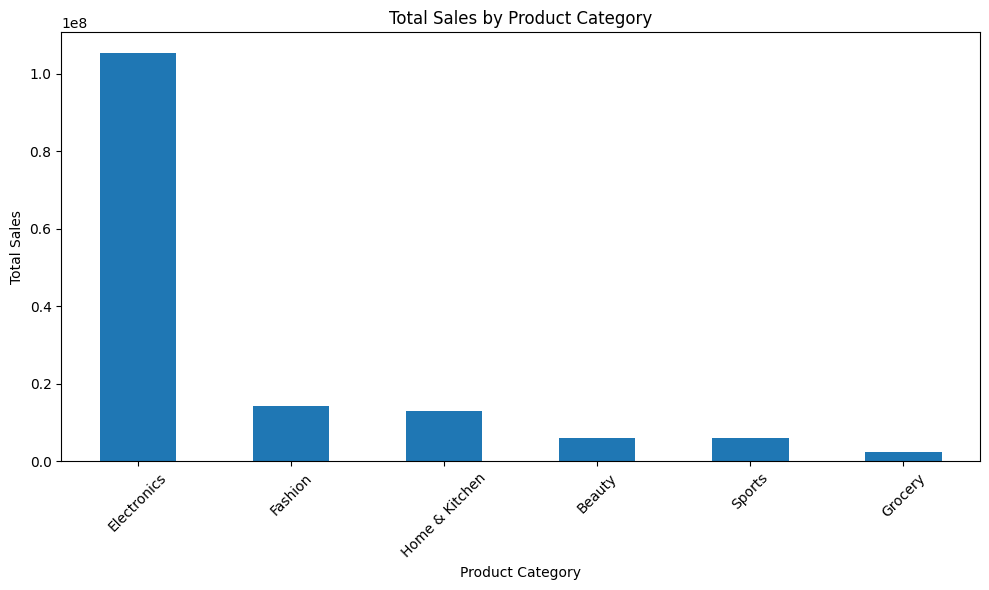

In [28]:
category_sales = df.groupby('Product_Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

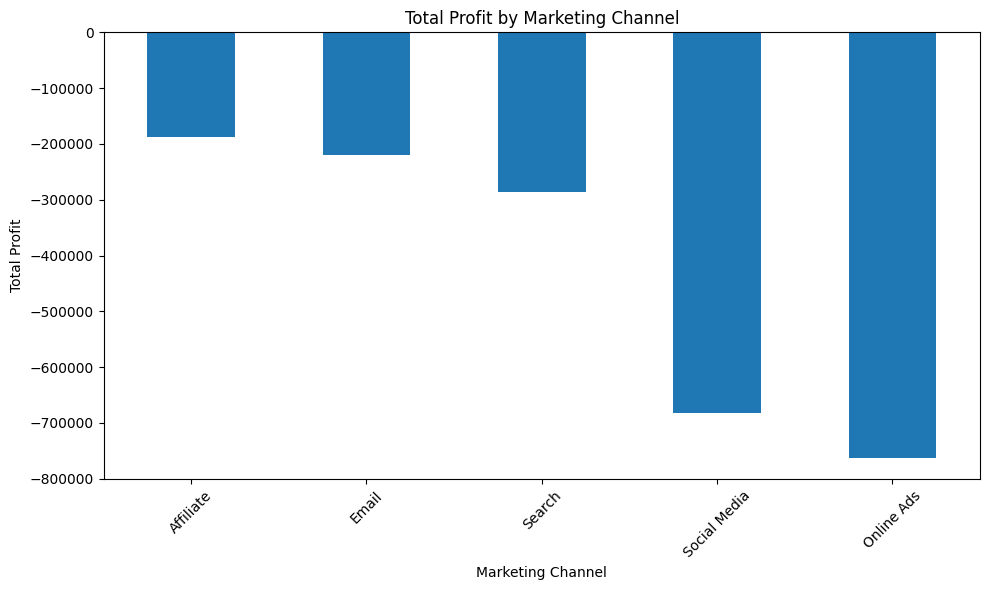

In [29]:
channel_profit = df.groupby('Marketing_Channel')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
channel_profit.plot(kind='bar')
plt.title('Total Profit by Marketing Channel')
plt.xlabel('Marketing Channel')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

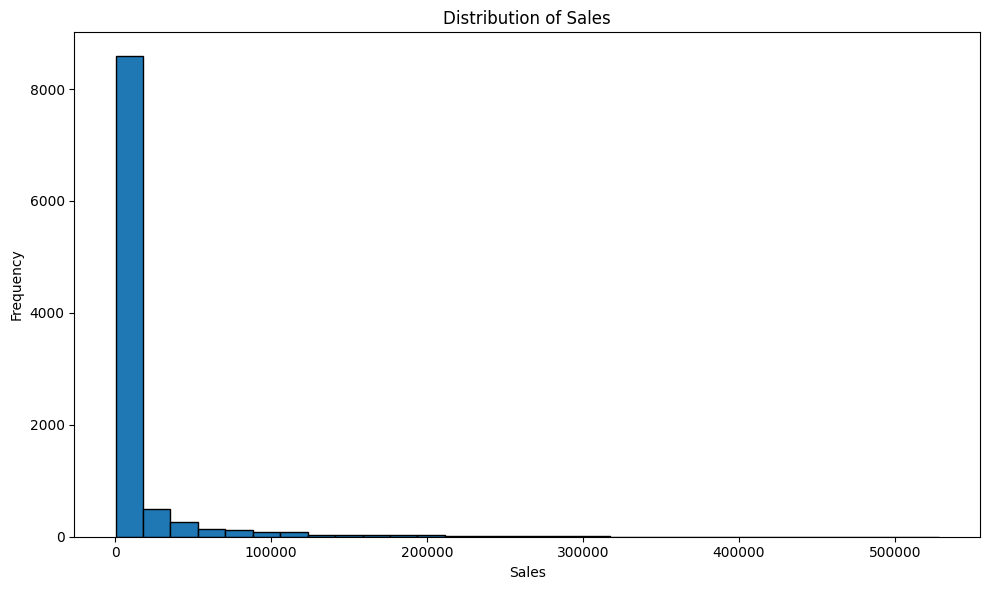

In [30]:
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=30, edgecolor='black')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

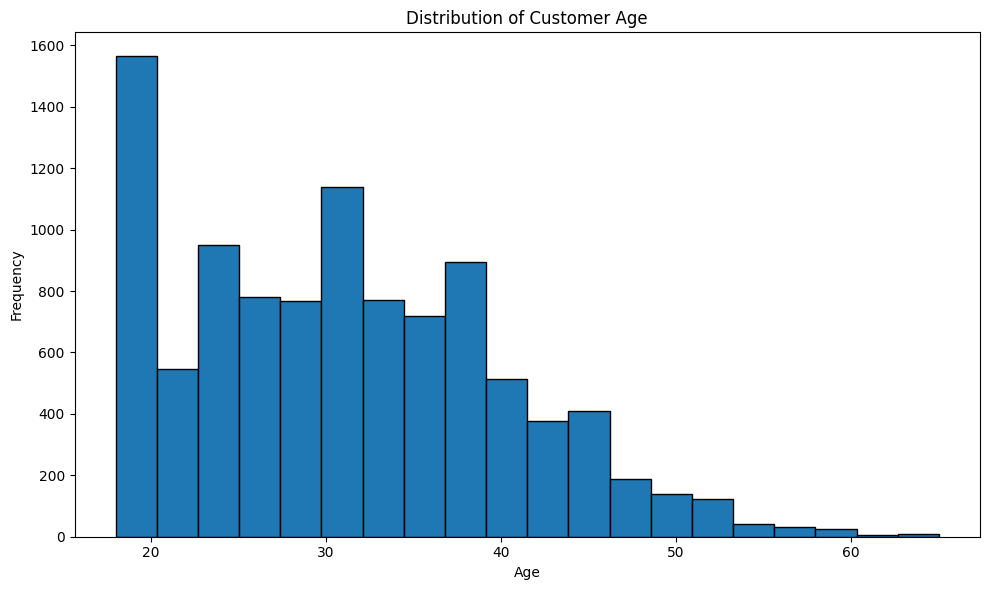

In [31]:
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=20, edgecolor='black')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

C:\Users\Admin\AppData\Local\Temp\ipykernel_13928\524159635.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=categories)


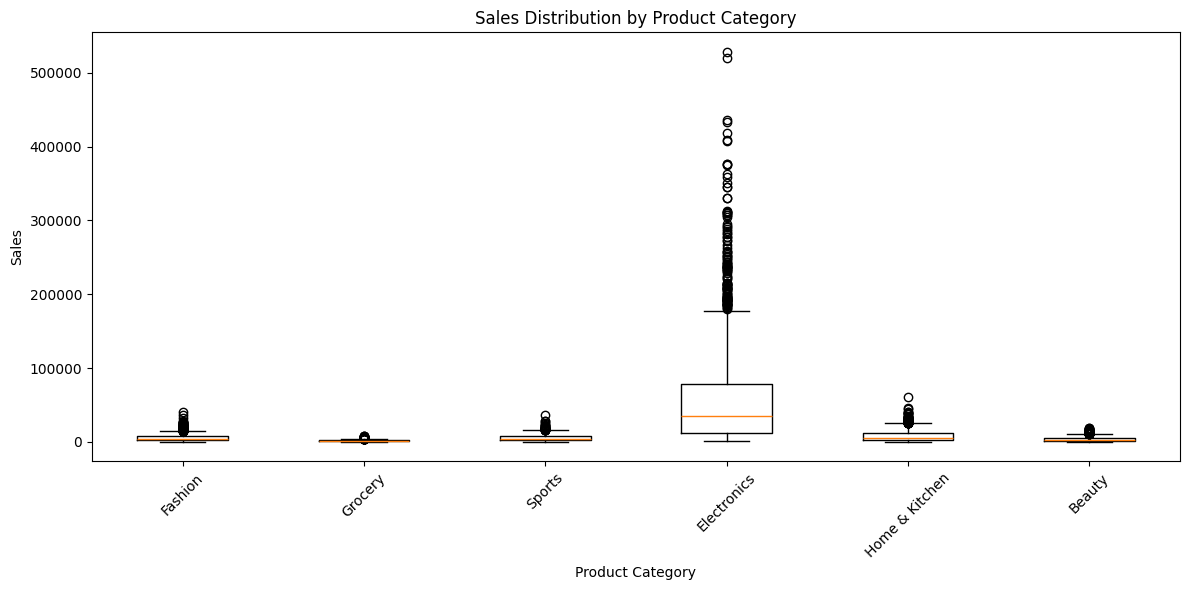

In [32]:
categories = df['Product_Category'].unique()

data = [
    df[df['Product_Category'] == category]['Sales']
    for category in categories
]

plt.figure(figsize=(12, 6))
plt.boxplot(data, labels=categories)
plt.title('Sales Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

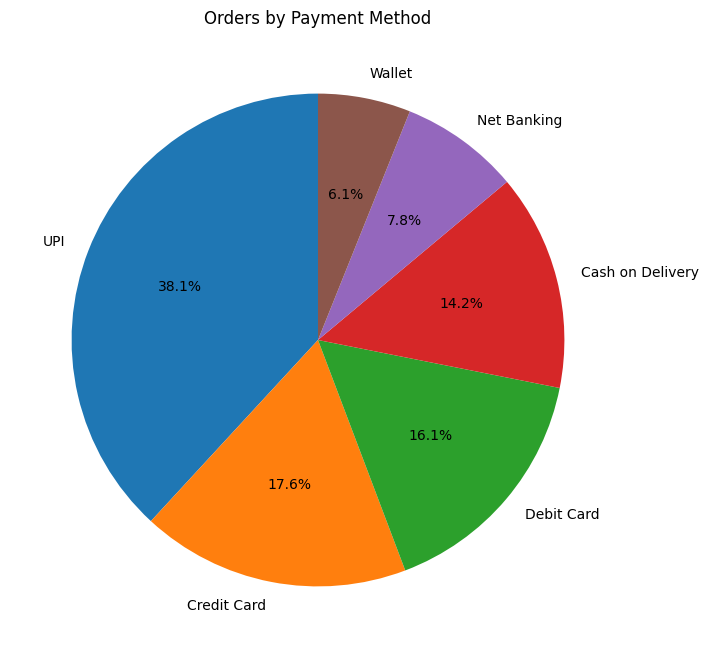

In [34]:
payment_counts = df['Payment_Method'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Orders by Payment Method')
plt.show()

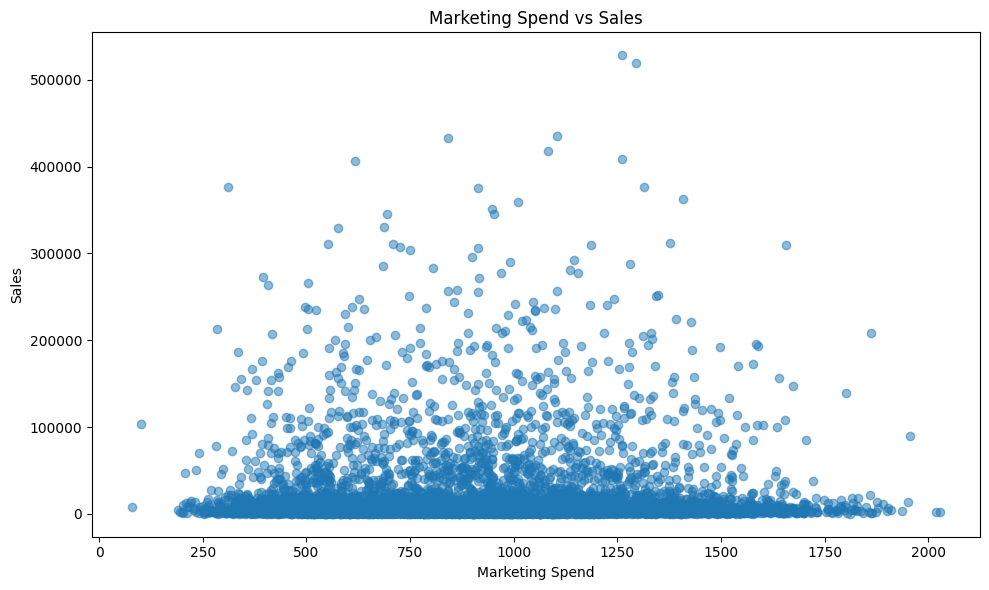

In [35]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Marketing_Spend'], df['Sales'], alpha=0.5)

plt.title('Marketing Spend vs Sales')
plt.xlabel('Marketing Spend')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

Gender
Male      73731606.70
Female    69089639.67
Other      4101980.69
Name: Sales, dtype: float64


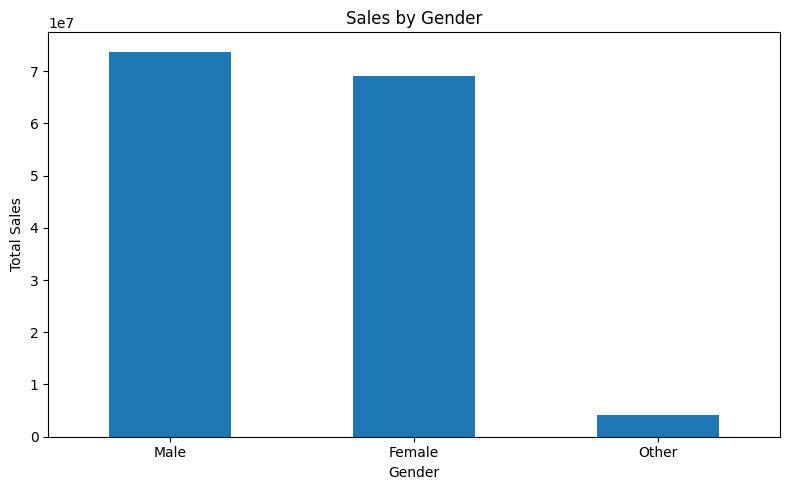

In [36]:
gender_sales = df.groupby('Gender')['Sales'].sum().sort_values(ascending=False)

print(gender_sales)

plt.figure(figsize=(8, 5))
gender_sales.plot(kind='bar')
plt.title('Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Region
West       56860721.92
North      35569262.63
South      26131156.87
Central    14432086.86
East       13929998.78
Name: Sales, dtype: float64


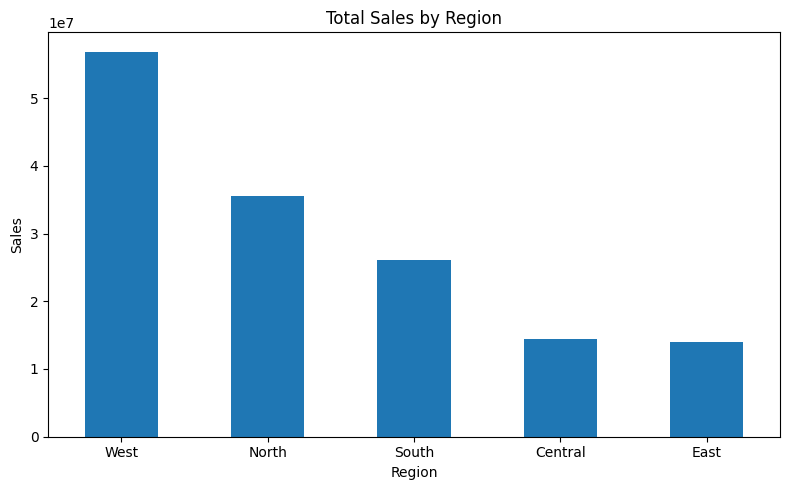

In [37]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

print(region_sales)

plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

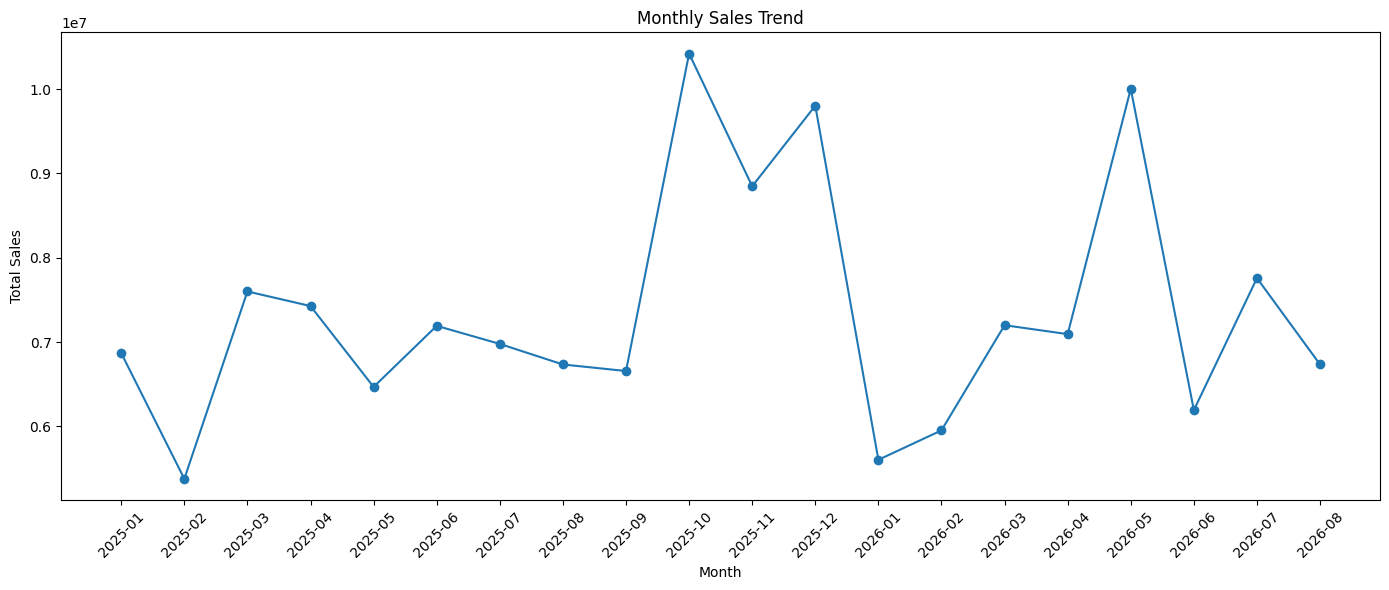

In [38]:
monthly_sales = df.groupby(
    df['Order_Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Product
Laptop           57051110.57
Smartphone       23013705.62
Tablet           17434756.29
Air Fryer         5395050.03
Smartwatch        5319559.56
Sneakers          4846475.74
Jacket            4044129.29
Mixer Grinder     3511413.03
Headphones        2549929.81
Jeans             2308159.61
Name: Sales, dtype: float64


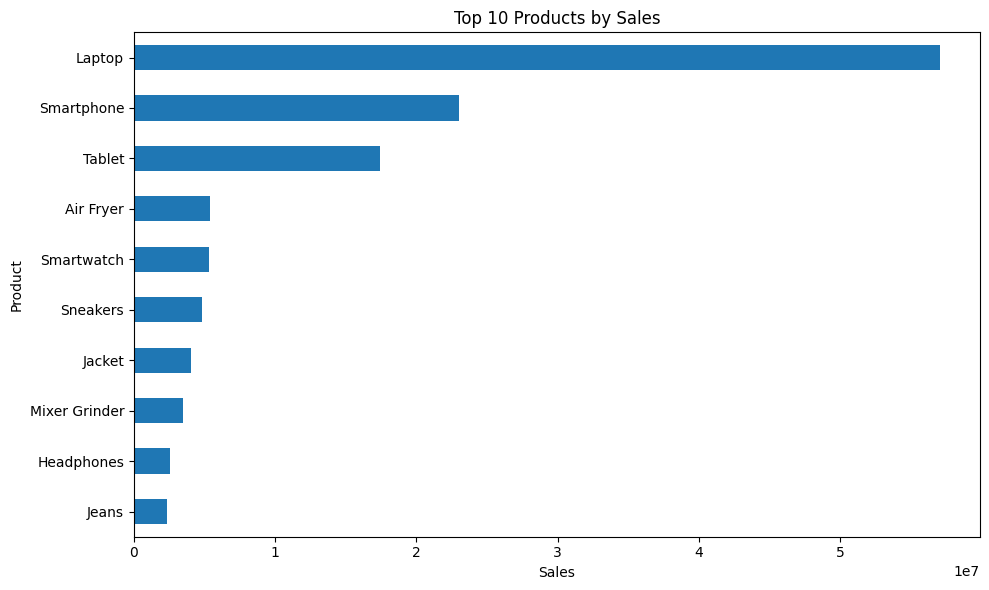

In [39]:
top_products = (
    df.groupby('Product')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [40]:
avg_channel_sales = (
    df.groupby('Marketing_Channel')['Sales']
    .mean()
    .sort_values(ascending=False)
)

print(avg_channel_sales)

Marketing_Channel
Search          16093.703543
Online Ads      15237.608206
Email           14301.495781
Social Media    13876.844660
Affiliate       13335.717148
Name: Sales, dtype: float64


In [41]:
conversion_counts = df['Conversion_Status'].value_counts()

print(conversion_counts)

conversion_rate = (
    (df['Conversion_Status'] == 'Converted').sum()
    / len(df)
) * 100

print("Overall Conversion Rate:", round(conversion_rate, 2), "%")

Conversion_Status
Not Converted    6123
Converted        3877
Name: count, dtype: int64
Overall Conversion Rate: 38.77 %


In [42]:
average_order_value = df['Sales'].mean()

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 14692.32


In [43]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order_ID'].nunique()
average_order_value = df['Sales'].mean()
total_quantity = df['Quantity'].sum()

print("========== BUSINESS KPIs ==========")
print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Average Order Value:", round(average_order_value, 2))
print("Total Quantity Sold:", total_quantity)

========== BUSINESS KPIs ==========
Total Sales: 146923227.06
Total Profit: -2136593.69
Total Orders: 10000
Average Order Value: 14692.32
Total Quantity Sold: 26838


In [44]:
print("Quantity <= 0:")
print(df[df['Quantity'] <= 0])

print("\nUnit Price <= 0:")
print(df[df['Unit_Price'] <= 0])

print("\nSales <= 0:")
print(df[df['Sales'] <= 0])

print("\nDiscount outside 0-100:")
print(df[(df['Discount'] < 0) | (df['Discount'] > 100)])

print("\nCustomer Rating outside 1-5:")
print(df[(df['Customer_Rating'] < 1) | (df['Customer_Rating'] > 5)])

Quantity <= 0:
Empty DataFrame
Columns: [Order_ID, Order_Date, Customer_ID, Age, Gender, City, Region, Product_Category, Product, Quantity, Unit_Price, Discount, Sales, Profit, Marketing_Channel, Campaign, Payment_Method, Customer_Rating, Marketing_Spend, Delivery_Days, Conversion_Status, Inventory_Available, Returned]
Index: []

Unit Price <= 0:
Empty DataFrame
Columns: [Order_ID, Order_Date, Customer_ID, Age, Gender, City, Region, Product_Category, Product, Quantity, Unit_Price, Discount, Sales, Profit, Marketing_Channel, Campaign, Payment_Method, Customer_Rating, Marketing_Spend, Delivery_Days, Conversion_Status, Inventory_Available, Returned]
Index: []

Sales <= 0:
Empty DataFrame
Columns: [Order_ID, Order_Date, Customer_ID, Age, Gender, City, Region, Product_Category, Product, Quantity, Unit_Price, Discount, Sales, Profit, Marketing_Channel, Campaign, Payment_Method, Customer_Rating, Marketing_Spend, Delivery_Days, Conversion_Status, Inventory_Available, Returned]
Index: []

Disco

In [45]:
def find_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\nColumn: {column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))

    return outliers

sales_outliers = find_outliers('Sales')


Column: Sales
Q1: 2010.6625
Q3: 10057.9525
IQR: 8047.289999999999
Lower Bound: -10060.272499999997
Upper Bound: 22128.887499999997
Number of Outliers: 1198


In [46]:
df.to_csv("ecommerce_business_analytics_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [47]:
# ==========================================
# Q45. DISTRIBUTION ANALYSIS
# ==========================================

sales = df["Sales"]

print("Sales Distribution Analysis")
print("--------------------------------")

print("Mean:", round(sales.mean(), 2))
print("Median:", round(sales.median(), 2))
print("Standard Deviation:", round(sales.std(), 2))
print("Minimum:", round(sales.min(), 2))
print("Maximum:", round(sales.max(), 2))
print("Skewness:", round(sales.skew(), 4))

Sales Distribution Analysis
--------------------------------
Mean: 14692.32
Median: 4323.52
Standard Deviation: 35831.04
Minimum: 175.36
Maximum: 528210.38
Skewness: 5.583


NameError: name 'OUT_DIR' is not defined

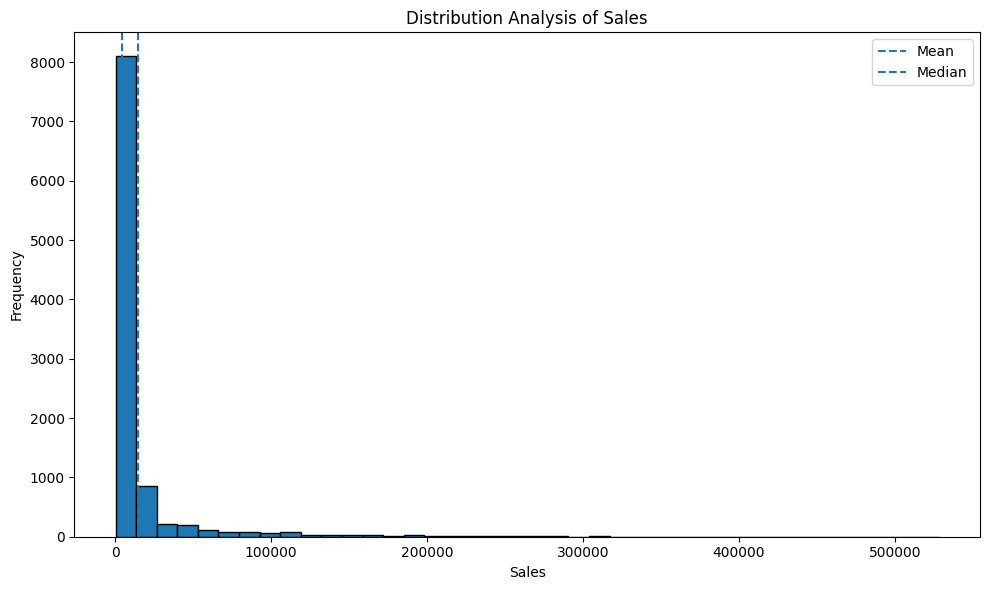

In [48]:
# ==========================================
# Q46. HISTOGRAM - SALES DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 6))

plt.hist(
    df["Sales"],
    bins=40,
    edgecolor="black"
)

plt.axvline(
    df["Sales"].mean(),
    linestyle="--",
    label="Mean"
)

plt.axvline(
    df["Sales"].median(),
    linestyle="--",
    label="Median"
)

plt.title("Distribution Analysis of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/21_distribution_sales_histogram.png",
    dpi=200
)

plt.show()

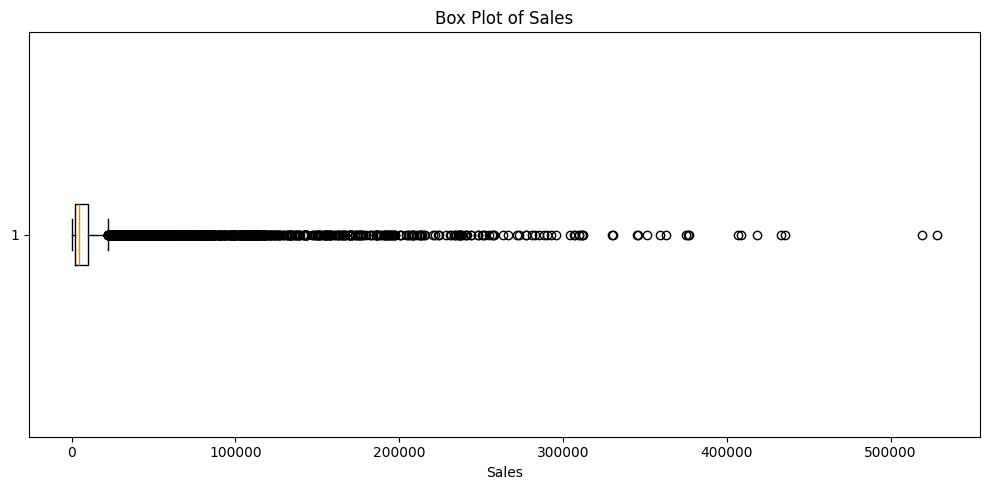

In [19]:
# =========================================================
# Q47. BOX PLOT - SALES DISTRIBUTION
# FIRST PROJECT: E-COMMERCE
# =========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

# Load FIRST project dataset
df = pd.read_csv(
    "ecommerce_business_analytics.csv"
)

# Create output folder
OUT_DIR = "shops_mart_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Correct column for FIRST project
sales = df["Sales"].dropna()

# Create Box Plot
plt.figure(figsize=(10, 5))

plt.boxplot(
    sales,
    vert=False
)

plt.title("Box Plot of Sales")
plt.xlabel("Sales")

plt.tight_layout()

# Save graph
plt.savefig(
    os.path.join(
        OUT_DIR,
        "22_distribution_sales_boxplot.png"
    ),
    dpi=200
)

plt.show()
plt.close()

In [20]:
# ==========================================
# Q48. OUTLIER ANALYSIS USING IQR
# ==========================================
df = pd.read_csv(
    "ecommerce_business_analytics.csv"
)
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Sales"] < lower_limit) |
    (df["Sales"] > upper_limit)
]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower Limit:", round(lower_limit, 2))
print("Upper Limit:", round(upper_limit, 2))
print("Number of Outliers:", len(outliers))

Q1: 2010.66
Q3: 10057.95
IQR: 8047.29
Lower Limit: -10060.27
Upper Limit: 22128.89
Number of Outliers: 1198


In [21]:
# ==========================================
# Q49. AUTOMATIC INTERPRETATION
# ==========================================
df = pd.read_csv(
    "ecommerce_business_analytics.csv"
)
skewness = df["Sales"].skew()

print("\nDistribution Interpretation")
print("---------------------------")

if skewness > 0.5:
    print("Sales distribution is positively skewed (right-skewed).")
elif skewness < -0.5:
    print("Sales distribution is negatively skewed (left-skewed).")
else:
    print("Sales distribution is approximately symmetric.")

print(
    f"The average sales value is ₹{df['Sales'].mean():,.2f}, "
    f"while the median sales value is ₹{df['Sales'].median():,.2f}."
)

print(
    f"The standard deviation is ₹{df['Sales'].std():,.2f}, "
    "indicating the spread of sales values."
)

print(
    f"The box plot identifies approximately {len(outliers)} observations "
    "outside the IQR-based limits."
)


Distribution Interpretation
---------------------------
Sales distribution is positively skewed (right-skewed).
The average sales value is ₹14,692.32, while the median sales value is ₹4,323.52.
The standard deviation is ₹35,831.04, indicating the spread of sales values.
The box plot identifies approximately 1198 observations outside the IQR-based limits.


In [22]:
# ==========================================
# Q50. DECISION MAKING UNDER UNCERTAINTY
# ==========================================
df = pd.read_csv(
    "ecommerce_business_analytics.csv"
)
alternatives = {
    "Search": {
        "High": 1.25,
        "Medium": 1.00,
        "Low": 0.75
    },
    "Online Ads": {
        "High": 1.30,
        "Medium": 1.00,
        "Low": 0.70
    },
    "Email": {
        "High": 1.20,
        "Medium": 1.00,
        "Low": 0.80
    }
}

probabilities = {
    "High": 0.25,
    "Medium": 0.50,
    "Low": 0.25
}

channel_avg_sales = df.groupby(
    "Marketing_Channel"
)["Sales"].mean()

print("Average Sales by Marketing Channel")
print(channel_avg_sales)

Average Sales by Marketing Channel
Marketing_Channel
Affiliate       13335.717148
Email           14301.495781
Online Ads      15237.608206
Search          16093.703543
Social Media    13876.844660
Name: Sales, dtype: float64


In [23]:
# ==========================================
# Q51. EXPECTED VALUE CALCULATION
# ==========================================
df = pd.read_csv(
    "ecommerce_business_analytics.csv"
)
decision_results = []

for channel, outcomes in alternatives.items():

    baseline = channel_avg_sales[channel]

    high_payoff = baseline * outcomes["High"]
    medium_payoff = baseline * outcomes["Medium"]
    low_payoff = baseline * outcomes["Low"]

    expected_value = (
        probabilities["High"] * high_payoff +
        probabilities["Medium"] * medium_payoff +
        probabilities["Low"] * low_payoff
    )

    decision_results.append({
        "Marketing Channel": channel,
        "High Payoff": high_payoff,
        "Medium Payoff": medium_payoff,
        "Low Payoff": low_payoff,
        "Expected Value": expected_value
    })

decision_df = pd.DataFrame(decision_results)

print("\nDecision Analysis")
print(decision_df.round(2))


Decision Analysis
  Marketing Channel  High Payoff  Medium Payoff  Low Payoff  Expected Value
0            Search     20117.13       16093.70    12070.28        16093.70
1        Online Ads     19808.89       15237.61    10666.33        15237.61
2             Email     17161.79       14301.50    11441.20        14301.50


In [24]:
# ==========================================
# Q52. BEST DECISION
# ==========================================
df = pd.read_csv(
    "ecommerce_business_analytics.csv"
)
best_decision = decision_df.loc[
    decision_df["Expected Value"].idxmax()
]

print("\nBest Marketing Decision")
print("-----------------------")
print(
    "Recommended Channel:",
    best_decision["Marketing Channel"]
)

print(
    "Maximum Expected Value:",
    round(best_decision["Expected Value"], 2)
)


Best Marketing Decision
-----------------------
Recommended Channel: Search
Maximum Expected Value: 16093.7


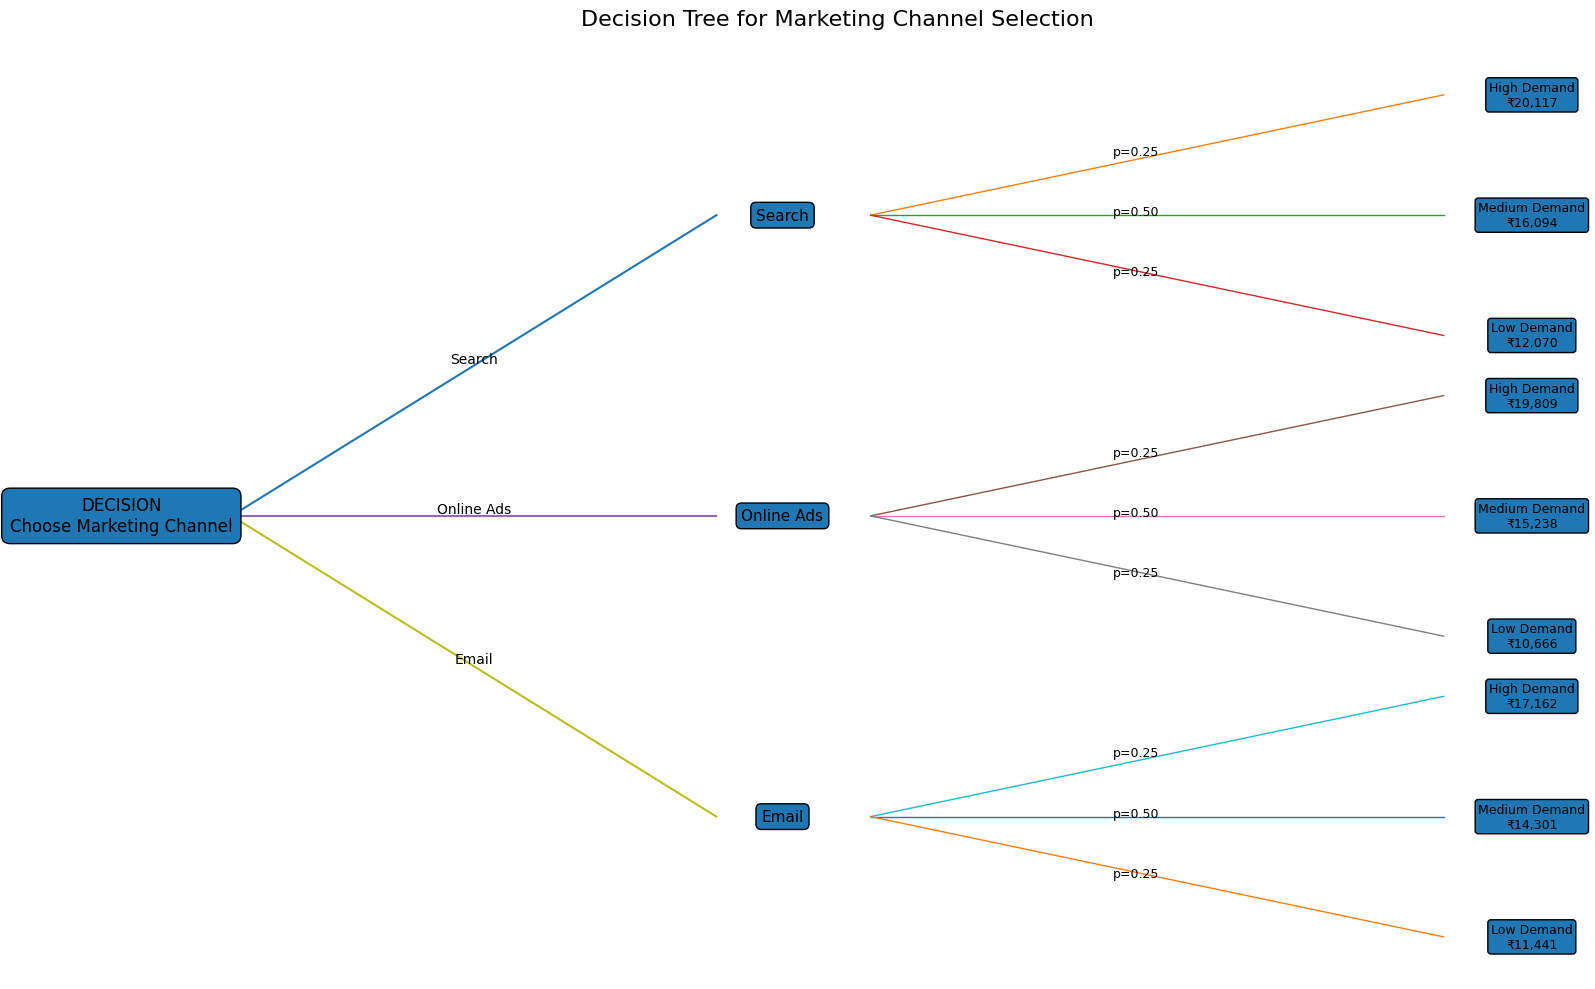

In [25]:
# ==========================================
# Q53. DECISION TREE VISUALIZATION
# ==========================================
df = pd.read_csv(
    "ecommerce_business_analytics.csv"
)
fig, ax = plt.subplots(figsize=(16, 10))

ax.axis("off")

# Decision point
ax.text(
    0.08, 0.50,
    "DECISION\nChoose Marketing Channel",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.5")
)

channels = list(alternatives.keys())

y_positions = [0.75, 0.50, 0.25]

for channel, y in zip(channels, y_positions):

    # Branch from decision to channel
    ax.plot(
        [0.13, 0.35],
        [0.50, y],
        linewidth=1.5
    )

    ax.text(
        0.24, (0.50 + y) / 2,
        channel,
        ha="center",
        va="bottom",
        fontsize=10
    )

    # Channel node
    ax.text(
        0.38, y,
        channel,
        ha="center",
        va="center",
        fontsize=11,
        bbox=dict(boxstyle="round,pad=0.35")
    )

    outcomes = ["High", "Medium", "Low"]
    outcome_y = [y + 0.10, y, y - 0.10]

    baseline = channel_avg_sales[channel]

    for outcome, oy in zip(outcomes, outcome_y):

        payoff = (
            baseline *
            alternatives[channel][outcome]
        )

        # Branch
        ax.plot(
            [0.42, 0.68],
            [y, oy],
            linewidth=1
        )

        # Probability
        ax.text(
            0.53,
            (y + oy) / 2,
            f"p={probabilities[outcome]:.2f}",
            fontsize=9
        )

        # Outcome
        ax.text(
            0.72,
            oy,
            f"{outcome} Demand\n₹{payoff:,.0f}",
            ha="center",
            va="center",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25")
        )

ax.set_title(
    "Decision Tree for Marketing Channel Selection",
    fontsize=16,
    pad=20
)

plt.tight_layout()

plt.savefig(
    f"{OUT_DIR}/23_decision_tree.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [26]:
df = pd.read_csv(
    "ecommerce_business_analytics.csv"
)
print("\nBusiness Interpretation:")
print(
    f"The marketing channel with the highest expected sales value is "
    f"{best_decision['Marketing Channel']}."
)

print(
    f"Its expected value is approximately "
    f"₹{best_decision['Expected Value']:,.2f}."
)


Business Interpretation:
The marketing channel with the highest expected sales value is Search.
Its expected value is approximately ₹16,093.70.
